[*********************100%%**********************]  1 of 1 completed
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
46/46 - 2s - 40ms/step - loss: 0.0810
Epoch 2/20
46/46 - 0s - 2ms/step - loss: 0.0168
Epoch 3/20
46/46 - 0s - 2ms/step - loss: 0.0171
Epoch 4/20
46/46 - 0s - 2ms/step - loss: 0.0175
Epoch 5/20
46/46 - 0s - 2ms/step - loss: 0.0194
Epoch 6/20
46/46 - 0s - 2ms/step - loss: 0.0147
Epoch 7/20
46/46 - 0s - 3ms/step - loss: 0.0194
Epoch 8/20
46/46 - 0s - 3ms/step - loss: 0.0181
Epoch 9/20
46/46 - 0s - 3ms/step - loss: 0.0125
Epoch 10/20
46/46 - 0s - 2ms/step - loss: 0.0129
Epoch 11/20
46/46 - 0s - 2ms/step - loss: 0.0127
Epoch 12/20
46/46 - 0s - 3ms/step - loss: 0.0129
Epoch 13/20
46/46 - 0s - 2ms/step - loss: 0.0128
Epoch 14/20
46/46 - 0s - 2ms/step - loss: 0.0138
Epoch 15/20
46/46 - 0s - 2ms/step - loss: 0.0125
Epoch 16/20
46/46 - 0s - 2ms/step - loss: 0.0113
Epoch 17/20
46/46 - 0s - 2ms/step - loss: 0.0129
Epoch 18/20
46/46 - 0s - 2ms/step - loss: 0.0106
Epoch 19/20
46/46 - 0s - 2ms/step - loss: 0.0141
Epoch 20/20
46/46 - 0s - 2ms/step - loss: 0.0090
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

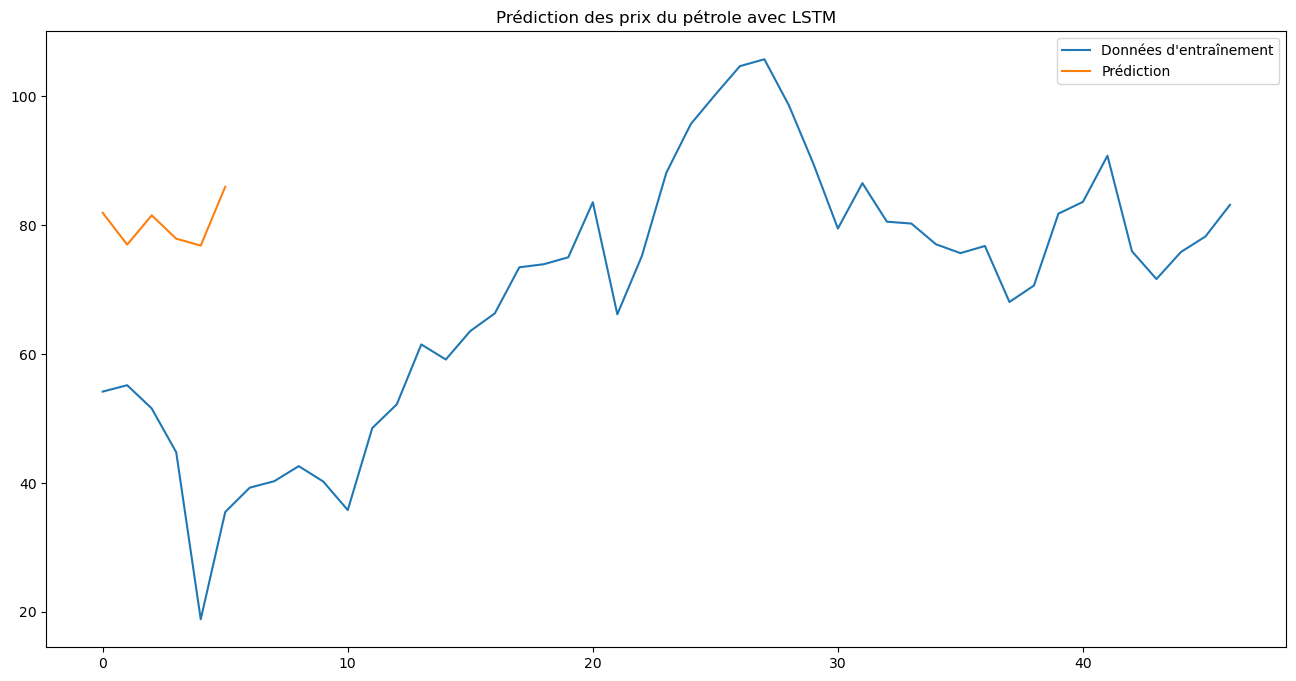

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
# Calculer la date actuelle et la date d'il y a 5 ans
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')

# Télécharger les données du pétrole pour les 5 dernières années
symbol = "CL=F"
data = yf.download(symbol, start=start_date, end=end_date, interval="1mo")

# Garder seulement la colonne 'Close' (prix de clôture)
prices = data['Close'].values
prices = prices.reshape(-1, 1)


# Normaliser les données
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Créer les séquences de données pour l'entraînement du modèle
def create_dataset(data, time_step=1):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 5  # Par exemple, utiliser les 5 derniers mois pour prédire le prochain
X, Y = create_dataset(scaled_prices, time_step)

# Reshape les données pour les rendre compatibles avec LSTM [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)




# Initialiser le modèle LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compiler le modèle
model.compile(optimizer='adam', loss='mean_squared_error')

# Entraîner le modèle
model.fit(X, Y, epochs=20, batch_size=1, verbose=2)


# Préparer les données pour la prédiction (utiliser les 5 derniers points de données)
last_data = scaled_prices[-time_step:]
last_data = last_data.reshape(1, time_step, 1)

# Prédire les prix futurs
predicted_price = model.predict(last_data)
predicted_price = scaler.inverse_transform(predicted_price)

print(f"Prix prédit pour le prochain mois: {predicted_price[0][0]}")


# Plot des données réelles et des prédictions
train = prices[:len(prices)-time_step]
valid = prices[len(prices)-time_step:]
valid = np.append(valid, predicted_price)

plt.figure(figsize=(16, 8))
plt.title('Prédiction des prix du pétrole avec LSTM')
plt.plot(train, label='Données d\'entraînement')
plt.plot(valid, label='Prédiction')
plt.legend()
plt.show()



In [2]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 73.5/73.5 kB 1.3 MB/s eta 0:00:00
     ---------------------------------------- 64.9/64.9 kB ? eta 0:00:00
     -------------------------------------- 505.5/505.5 kB 5.3 MB/s eta 0:00:00
     -------------------------------------- 112.2/112.2 kB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 3.0/3.0 MB 11.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for peewee: filename=peewee-3.17.6-py3-none-any.whl size=138938 sha256=4649040063ea09e78ab607acd85fe989b98811e6250eb190627952df584522c5
  Stored in directory: c:\users\user\appdata\loc

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-project 0.11.1 requires ruamel-yaml, which is not installed.
conda-repo-cli 1.0.20 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.20 requires nbformat==5.4.0, but you have nbformat 5.5.0 which is incompatible.
conda-repo-cli 1.0.20 requires requests==2.28.1, but you have requests 2.32.3 which is incompatible.


In [6]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Calculer la date actuelle et la date d'il y a 5 ans
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=10*365)).strftime('%Y-%m-%d')

# Télécharger les données du pétrole pour les 5 dernières années
symbol = "CL=F"  # Le symbole pour le pétrole brut WTI
data = yf.download(symbol, start=start_date, end=end_date, interval="1mo")

# Afficher les premières lignes des données
print(data.head())

# Sauvegarder les données dans un fichier CSV
data.to_csv("petrol_prices.csv")


[*********************100%%**********************]  1 of 1 completed

                 Open       High        Low      Close  Adj Close   Volume
Date                                                                      
2014-09-01  95.809998  95.910004  90.430000  91.160004  91.160004  5762880
2014-10-01  91.360001  92.959999  79.440002  80.540001  80.540001  7448385
2014-11-01  80.589996  80.980003  65.690002  66.150002  66.150002  6055929
2014-12-01  66.000000  69.540001  52.439999  53.270000  53.270000  6919717
2015-01-01  53.759998  55.110001  43.580002  48.240002  48.240002  7699363


In [8]:

df = pd.read_csv('petrol_prices.csv')


In [9]:
df.shape


(104, 7)

In [13]:
df.drop(['Date', 'Volume'], axis=1, inplace=True)

KeyError: "['Date', 'Volume'] not found in axis"

In [14]:
df.drop(['Adj Close'], axis=1, inplace=True)

In [15]:
df.head()


,Open,High,Low,Close
0,95.809998,95.910004,90.430000,91.160004
1,91.360001,92.959999,79.440002,80.540001
2,80.589996,80.980003,65.690002,66.150002
3,66.000000,69.540001,52.439999,53.270000
4,53.759998,55.110001,43.580002,48.240002


In [16]:
df.corr()


,Open,High,Low,Close
Open,1.000000,0.971456,0.931398,0.941252
High,0.971456,1.000000,0.922457,0.967602
Low,0.931398,0.922457,1.000000,0.944106
Close,0.941252,0.967602,0.944106,1.000000


In [17]:
from sklearn.model_selection import train_test_split


In [18]:
xTrain, xTest, yTrain, yTest = train_test_split(df.drop(['Close'], axis=1), df['Close'], test_size=0.2, random_state=42)


In [19]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [20]:
model1 = LinearRegression()
model2 = XGBRegressor()
model3 = RandomForestRegressor()

In [21]:

model1.fit(xTrain, yTrain)
model2.fit(xTrain, yTrain)
model3.fit(xTrain, yTrain)

RandomForestRegressor()

In [22]:
yPred1 = model1.predict(xTest)
yPred2 = model2.predict(xTest)
yPred3 = model3.predict(xTest)

In [23]:
from sklearn.metrics import mean_squared_error


In [24]:
print('Linear Regression: ', np.sqrt(mean_squared_error(yTest, yPred1)))
print('XGBoost: ', np.sqrt(mean_squared_error(yTest, yPred2)))
print('Random Forest: ', np.sqrt(mean_squared_error(yTest, yPred3)))

Linear Regression:  6.185336986269115
XGBoost:  4.070652052256514
Random Forest:  2.810387592238714


In [25]:
from sklearn.metrics import r2_score


In [26]:

print('Linear Regression: ', r2_score(yTest, yPred1))
print('XGBoost: ', r2_score(yTest, yPred2))
print('Random Forest: ', r2_score(yTest, yPred3))


Linear Regression:  0.8945756797939235
XGBoost:  0.9543393550560304
Random Forest:  0.9782356091305788


In [27]:
model1.predict([[23.04, 25.05, 22.98]])

C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([25.7972834])

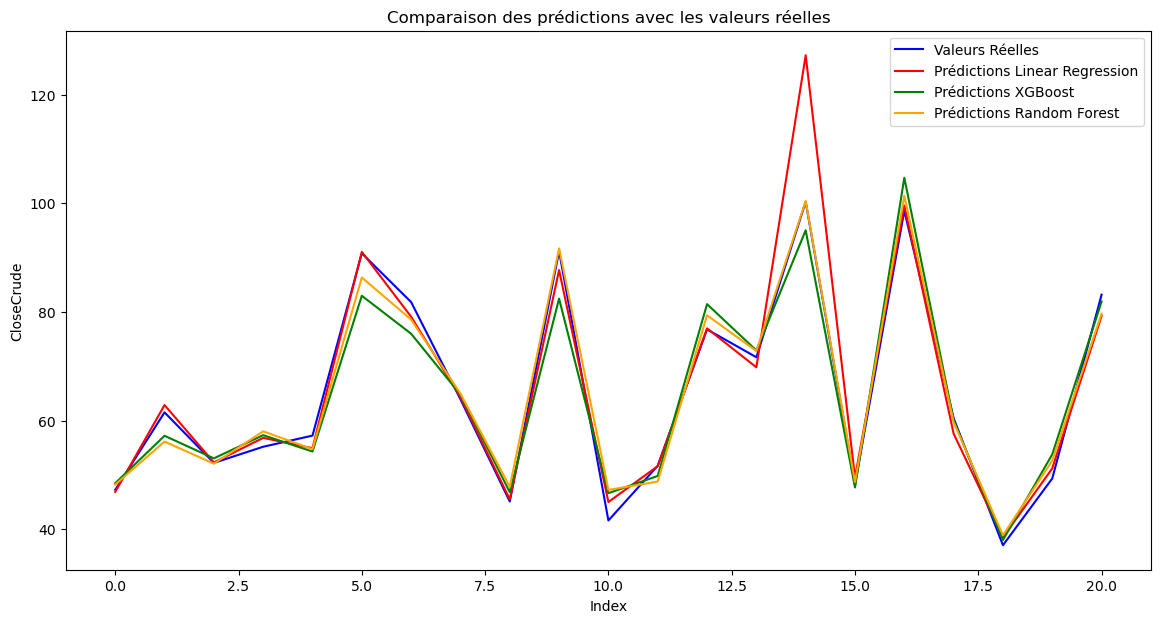

In [28]:
import matplotlib.pyplot as plt

# Comparer les prédictions avec les valeurs réelles
plt.figure(figsize=(14, 7))
plt.plot(yTest.values, label='Valeurs Réelles', color='blue')
plt.plot(yPred1, label='Prédictions Linear Regression', color='red')
plt.plot(yPred2, label='Prédictions XGBoost', color='green')
plt.plot(yPred3, label='Prédictions Random Forest', color='orange')
plt.legend()
plt.xlabel('Index')
plt.ylabel('CloseCrude')
plt.title('Comparaison des prédictions avec les valeurs réelles')
plt.show()


Prédictions pour les 12 prochains mois (CloseCrude) :
[76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777, 76.90069786071777]


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature nam

[*********************100%%**********************]  1 of 1 completed
C:\Users\user\AppData\Local\Temp\ipykernel_60264\690208231.py:61: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=13, freq='M')[1:]


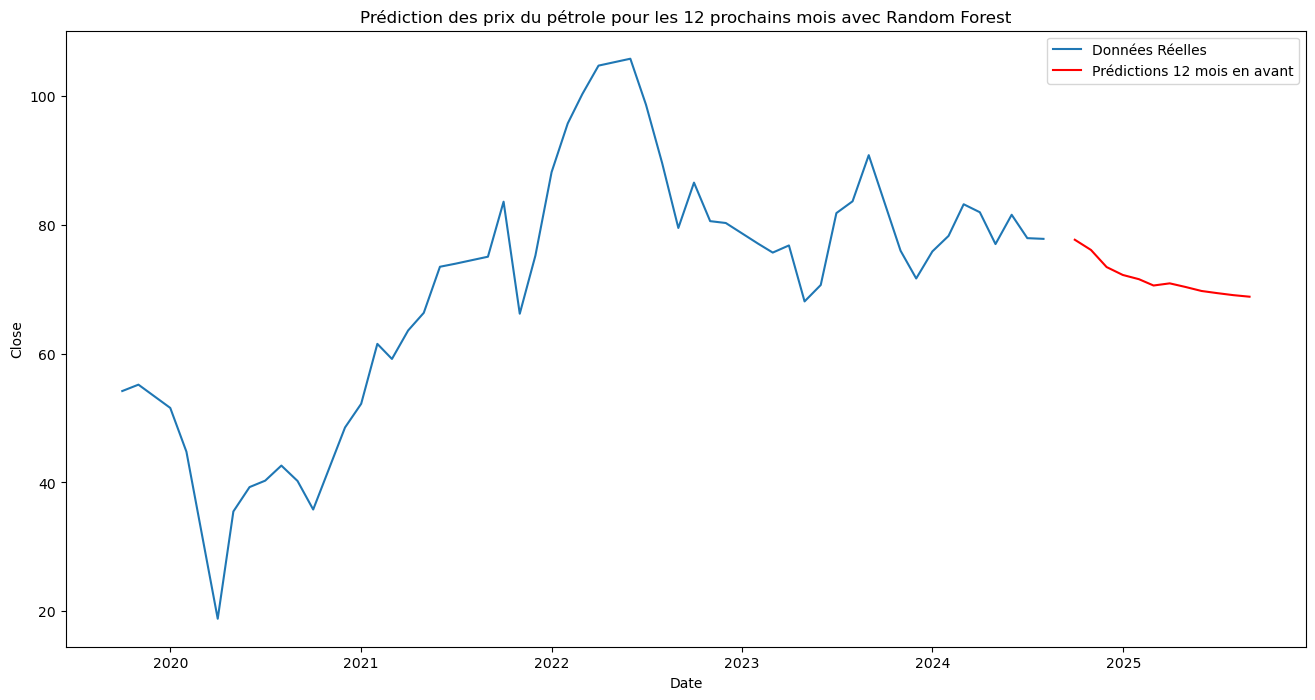

[*********************100%%**********************]  1 of 1 completed
C:\Users\user\AppData\Local\Temp\ipykernel_60264\2228604638.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Close'] = scaler.fit_transform(df[['Close']])
C:\Users\user\AppData\Local\Temp\ipykernel_60264\2228604638.py:99: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(start=df.index[-1] + timedelta(days=30), periods=12, freq='M'), future_df['Close'], label='Prédictions', color='red')


Linear Regression - RMSE: 0.17360563978647597
XGBoost - RMSE: 0.07910133131378591
Random Forest - RMSE: 0.08523973211421927
Linear Regression - R^2: 0.37254701102494203
XGBoost - R^2: 0.8697369870489627
Random Forest - R^2: 0.8487352668627325
Le meilleur modèle est : XGBRegressor
    Year  Month      Close
0   2024      9  75.357071
1   2024     10  79.534973
2   2024     11  74.565300
3   2024      0  75.918930
4   2024      1  75.918930
5   2024      2  78.395988
6   2024      3  78.147568
7   2024      4  81.797386
8   2024      5  77.003563
9   2024      6  80.963463
10  2024      7  77.978752
11  2024      8  77.201019


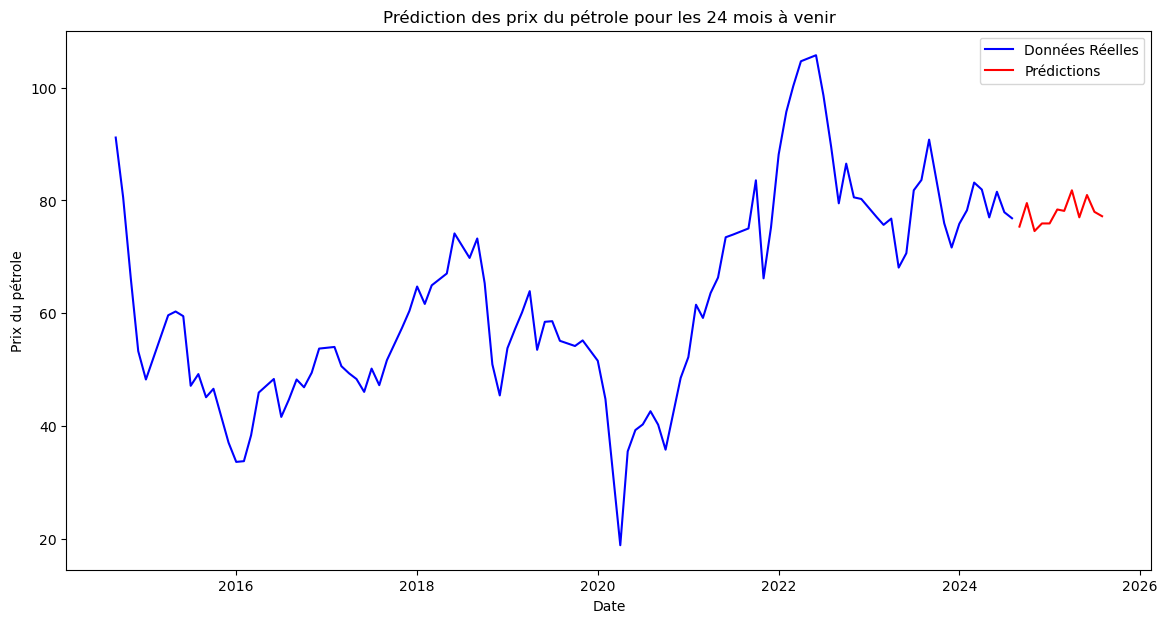

In [47]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Télécharger les données du pétrole pour les 10 dernières années
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=10*365)).strftime('%Y-%m-%d')

symbol = "CL=F"
data = yf.download(symbol, start=start_date, end=end_date, interval="1mo")

# Préparer les données
data['Month'] = data.index.month
data['Year'] = data.index.year
df = data[['Close', 'Month', 'Year']]

# Normaliser les prix
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df[['Close']])

# Diviser les données en ensemble d'entraînement et de test
X = df[['Month', 'Year']]
y = df['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser les modèles
model_lr = LinearRegression()
model_xgb = XGBRegressor()
model_rf = RandomForestRegressor()

# Entraîner les modèles
model_lr.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred_lr = model_lr.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Évaluer les modèles
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_lr = r2_score(y_test, y_pred_lr)
r2_xgb = r2_score(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)

print('Linear Regression - RMSE:', rmse_lr)
print('XGBoost - RMSE:', rmse_xgb)
print('Random Forest - RMSE:', rmse_rf)

print('Linear Regression - R^2:', r2_lr)
print('XGBoost - R^2:', r2_xgb)
print('Random Forest - R^2:', r2_rf)

# Choisir le meilleur modèle
best_model = None
if rmse_lr == min(rmse_lr, rmse_xgb, rmse_rf):
    best_model = model_lr
elif rmse_xgb == min(rmse_lr, rmse_xgb, rmse_rf):
    best_model = model_xgb
else:
    best_model = model_rf

print(f"Le meilleur modèle est : {best_model.__class__.__name__}")

# Préparer les données pour prédiction des 24 mois à venir
last_month = df.index[-1]
last_year = last_month.year
future_dates = [(last_year, month) for month in range(last_month.month + 1, last_month.month + 13)]

future_df = pd.DataFrame(future_dates, columns=['Year', 'Month'])
future_df['Month'] = future_df['Month'] % 12  # Corriger les mois qui dépassent 12
future_df['Close'] = np.nan  # Ajouter une colonne 'Close' vide pour la prédiction

# Prédire les prix futurs avec le meilleur modèle
future_X = future_df[['Month', 'Year']]
future_df['Close'] = best_model.predict(future_X)

# Inverser la normalisation pour obtenir les prix réels
future_df['Close'] = scaler.inverse_transform(future_df[['Close']])

# Afficher les prévisions
print(future_df)

# Plot des données réelles et des prévisions
plt.figure(figsize=(14, 7))
plt.plot(df.index, scaler.inverse_transform(df[['Close']]), label='Données Réelles', color='blue')
plt.plot(pd.date_range(start=df.index[-1] + timedelta(days=30), periods=12, freq='M'), future_df['Close'], label='Prédictions', color='red')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Prix du pétrole')
plt.title('Prédiction des prix du pétrole pour les 24 mois à venir')
plt.show()


[*********************100%%**********************]  1 of 1 completed
C:\Users\user\AppData\Local\Temp\ipykernel_26428\2876722186.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Close'] = scaler.fit_transform(df[['Close']])
C:\Users\user\AppData\Local\Temp\ipykernel_26428\2876722186.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(start=df.index[-1] + timedelta(days=30), periods=12, freq='M'), future_df['Close'], label='Prédictions', color='red')


Linear Regression - RMSE: 0.17360563978647597
XGBoost - RMSE: 0.07910133131378591
Random Forest - RMSE: 0.08675823273200789
Linear Regression - R^2: 0.37254701102494203
XGBoost - R^2: 0.8697369870489627
Random Forest - R^2: 0.8432978602090164
Le meilleur modèle est : XGBRegressor
    Year  Month      Close First_Day_of_Month
0   2024      9  75.357071         2024-09-01
1   2024     10  79.534973         2024-10-01
2   2024     11  74.565300         2024-11-01
3   2024     12  74.940697         2024-12-01
4   2025      1  75.918930         2025-01-01
5   2024      2  78.395988         2024-02-01
6   2024      3  78.147568         2024-03-01
7   2024      4  81.797386         2024-04-01
8   2024      5  77.003563         2024-05-01
9   2024      6  80.963463         2024-06-01
10  2024      7  77.978752         2024-07-01
11  2024      8  77.201019         2024-08-01
La table dim_pred_oil_price a été créée (ou elle existe déjà).
Données existantes supprimées avec succès.
Les données ont

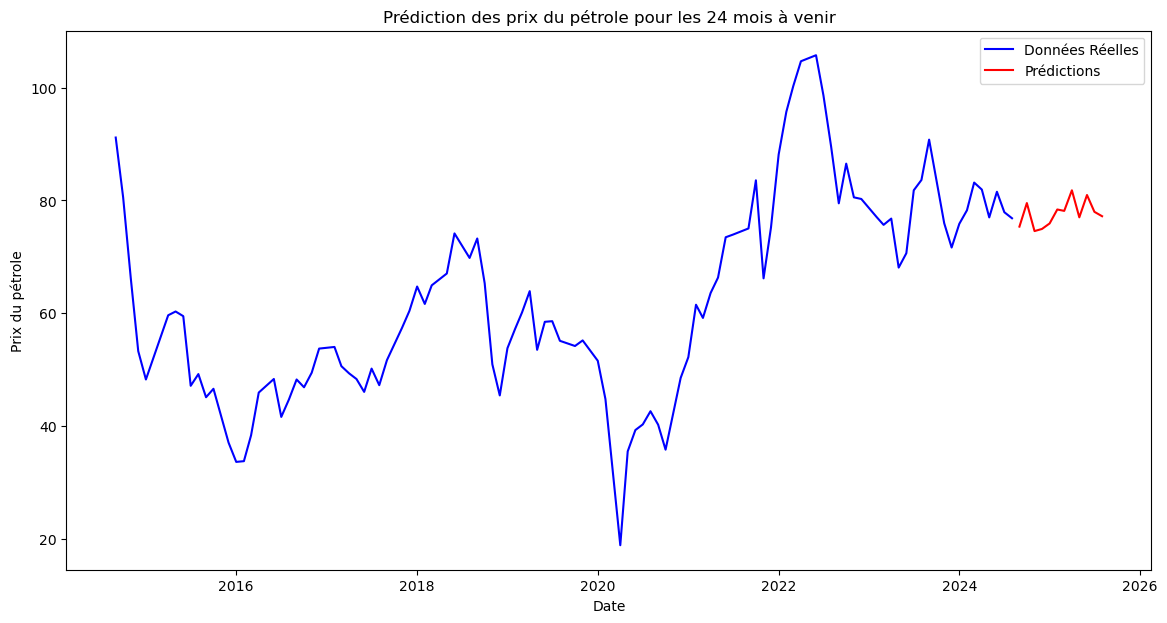

In [5]:
import pyodbc
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Télécharger les données du pétrole pour les 10 dernières années
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=10*365)).strftime('%Y-%m-%d')

symbol = "CL=F"
data = yf.download(symbol, start=start_date, end=end_date, interval="1mo")

# Convertir l'index en DatetimeIndex pour accéder aux attributs 'month' et 'year'
data.index = pd.to_datetime(data.index)

# Préparer les données
data['Month'] = data.index.month
data['Year'] = data.index.year
df = data[['Close', 'Month', 'Year']]

# Normaliser les prix
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df[['Close']])

# Diviser les données en ensemble d'entraînement et de test
X = df[['Month', 'Year']]
y = df['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser les modèles
model_lr = LinearRegression()
model_xgb = XGBRegressor()
model_rf = RandomForestRegressor()

# Entraîner les modèles
model_lr.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Prédire les valeurs sur l'ensemble de test
y_pred_lr = model_lr.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Évaluer les modèles
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_lr = r2_score(y_test, y_pred_lr)
r2_xgb = r2_score(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)

print('Linear Regression - RMSE:', rmse_lr)
print('XGBoost - RMSE:', rmse_xgb)
print('Random Forest - RMSE:', rmse_rf)

print('Linear Regression - R^2:', r2_lr)
print('XGBoost - R^2:', r2_xgb)
print('Random Forest - R^2:', r2_rf)

# Choisir le meilleur modèle
best_model = None
if rmse_lr == min(rmse_lr, rmse_xgb, rmse_rf):
    best_model = model_lr
elif rmse_xgb == min(rmse_lr, rmse_xgb, rmse_rf):
    best_model = model_xgb
else:
    best_model = model_rf

print(f"Le meilleur modèle est : {best_model.__class__.__name__}")

# Préparer les données pour prédiction des 24 mois à venir
last_month = df.index[-1]
last_year = last_month.year
future_dates = [(last_year, month) for month in range(last_month.month + 1, last_month.month + 13)]

future_df = pd.DataFrame(future_dates, columns=['Year', 'Month'])

# Ajuster les mois pour qu'ils soient entre 1 et 12
future_df['Month'] = (future_df['Month'] - 1) % 12 + 1
future_df['Year'] = future_df['Year'] + (future_df['Month'] == 1).astype(int)  # Incrémenter l'année si mois est 1

future_df['Close'] = np.nan  # Ajouter une colonne 'Close' vide pour la prédiction

# Prédire les prix futurs avec le meilleur modèle
future_X = future_df[['Month', 'Year']]
future_df['Close'] = best_model.predict(future_X)

# Inverser la normalisation pour obtenir les prix réels
future_df['Close'] = scaler.inverse_transform(future_df[['Close']])

# Ajouter la colonne 'First_Day_of_Month'
future_df['First_Day_of_Month'] = pd.to_datetime(future_df['Year'].astype(str) + '-' + future_df['Month'].astype(str).str.zfill(2) + '-01')

# Afficher les prévisions
print(future_df)

# Connexion à la base de données SQL
conn = pyodbc.connect('DRIVER={SQL Server};SERVER=LAPTOP-HED7JE2F;DATABASE=PGS_STAGE_DW;UID=sa;PWD=sa@123@123')
cursor = conn.cursor()

# Créer la table si elle n'existe pas
create_table_query = '''
IF NOT EXISTS (
    SELECT * FROM INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_NAME = 'dim_pred_oil_price'
)
BEGIN
    CREATE TABLE dim_pred_oil_price (
        First_Day_of_Month DATE PRIMARY KEY,
        Forecast FLOAT
    )
END
'''
cursor.execute(create_table_query)
conn.commit()
print("La table dim_pred_oil_price a été créée (ou elle existe déjà).")

# Supprimer les données existantes avant l'insertion
cursor.execute("DELETE FROM dim_pred_oil_price")
print("Données existantes supprimées avec succès.")

# Préparer les données pour l'insertion
data_to_insert = future_df[['First_Day_of_Month', 'Close']].values.tolist()

# Requête d'insertion de données
insert_query = '''
INSERT INTO dim_pred_oil_price (First_Day_of_Month, Forecast)
VALUES (?, ?)
'''

# Exécuter la requête d'insertion de données pour chaque tuple
cursor.executemany(insert_query, data_to_insert)

# Valider les modifications
conn.commit()

# Fermer la connexion
conn.close()

print("Les données ont été insérées avec succès dans la table dim_pred_oil_price.")

# Plot des données réelles et des prévisions
plt.figure(figsize=(14, 7))
plt.plot(df.index, scaler.inverse_transform(df[['Close']]), label='Données Réelles', color='blue')
plt.plot(pd.date_range(start=df.index[-1] + timedelta(days=30), periods=12, freq='M'), future_df['Close'], label='Prédictions', color='red')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Prix du pétrole')
plt.title('Prédiction des prix du pétrole pour les 24 mois à venir')
plt.show()


In [51]:
pip install pymysql

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 45.0/45.0 kB 551.3 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pyodbc

# Connexion à la base de données SQL
conn = pyodbc.connect('DRIVER={SQL Server};SERVER=LAPTOP-HED7JE2F;DATABASE=PGS_STAGE_DW;UID=sa;PWD=sa@123@123')
cursor = conn.cursor()

# Créer la table oil_price si elle n'existe pas déjà
create_table_query = '''
IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='Dim_oil_price' AND xtype='U')
CREATE TABLE Dim_oil_price (
    Date DATE  PRIMARY KEY ,
    price FLOAT
)
'''
cursor.execute(create_table_query)

# Préparer les données pour l'insertion
data_to_insert = [(row.name, row.Close) for index, row in data.iterrows()]

# Requête d'insertion de données
insert_query = '''
INSERT INTO Dim_oil_price (Date, price)
VALUES (?, ?)
'''

# Exécuter la requête d'insertion de données pour chaque ligne
cursor.executemany(insert_query, data_to_insert)

# Valider les modifications
conn.commit()

# Fermer la connexion
conn.close()

print("Les données ont été insérées avec succès dans la table oil_price.")


Les données ont été insérées avec succès dans la table oil_price.
